In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


In [2]:
# Load repository-provided local validation data

DATA_DIR = Path("data")

tas_path = DATA_DIR / "tas_southamerica_2015.nc"
tasmin_path = DATA_DIR / "tasmin_southamerica_2015.nc"
tasmax_path = DATA_DIR / "tasmax_southamerica_2015.nc"
pr_path = DATA_DIR / "pr_southamerica_2015.nc"

tas = xr.open_dataset(tas_path)
tasmin = xr.open_dataset(tasmin_path)
tasmax = xr.open_dataset(tasmax_path)
pr = xr.open_dataset(pr_path)

In [3]:
# Check the units

# Correct temperature values
tas["tas"] = tas["tas"] - 273.15 
tasmin["tasmin"] = tasmin["tasmin"] - 273.15
tasmax["tasmax"] = tasmax["tasmax"] - 273.15

# Correct precipitation values
pr["pr"] = pr["pr"] * 86400 # more information below


### Background information on precipitation unit

The precipitation in reanalysis data sets is given in $\frac{kg}{m^2 \cdot s}$, i.e mass per $m^2$ and $s$, where the mass describes the weight of the raindrop. To convert this into $\frac{mm}{day}$ we have to multiply by $60 \cdot 60 \cdot 24 = 86400$. This is because $\frac{kg}{m^2}$ equals 1 $mm$ of precipitation. 1 $mm$ of precipitation is defined as the rise hight of water on a 1 $m^2$ area. Since the density of water is $\approx 1000 \frac{kg}{m^3}$ one kg of water has a volumen of $\frac{1}{1000} m^3$. Every mm of hight takes a volumen of $1 mm \times m^2 = \frac{1}{1000} m^3$. 

In [4]:
# Consider time series in Belem for one year:

lat_belem, lon_belem = -1.45, -48.74 

belem_tas = tas.sel(longitude=lon_belem, latitude=lat_belem, method ="nearest")
belem_tasmin = tasmin.sel(longitude=lon_belem, latitude=lat_belem, method ="nearest")
belem_tasmax = tasmax.sel(longitude=lon_belem, latitude=lat_belem, method ="nearest")
belem_pr = pr.sel(longitude=lon_belem, latitude=lat_belem, method ="nearest")

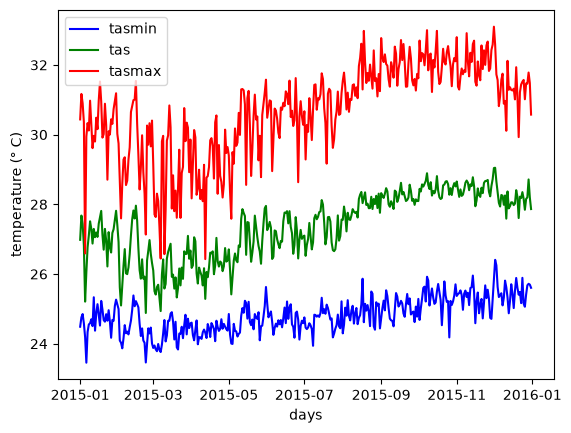

In [5]:
# Check temperatur

plt.figure()
plt.plot(belem_tasmin["time"], belem_tasmin["tasmin"] , color="blue", label = "tasmin")
plt.plot(belem_tas["time"], belem_tas["tas"], color="green", label = "tas")
plt.plot(belem_tasmax["time"], belem_tasmax["tasmax"], color="red", label = "tasmax")
plt.xlabel("days")
plt.ylabel("temperature (° C)")
plt.legend()

Text(0, 0.5, 'mm/day')

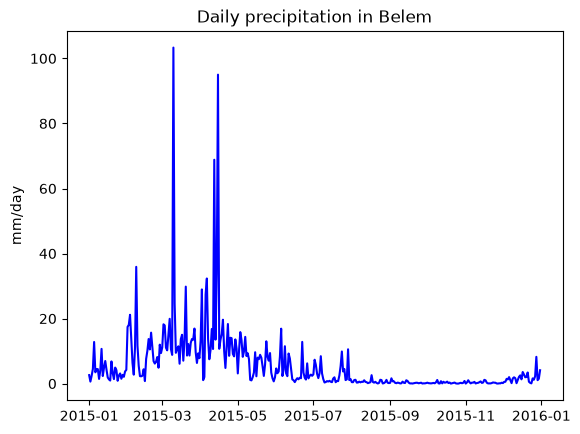

In [6]:
# Check precipitation 

plt.figure()
plt.plot(belem_pr["time"], belem_pr["pr"], color = "blue")
plt.title("Daily precipitation in Belem")
plt.ylabel("mm/day")

In [7]:
# Calculate monthly mean

tas_monthly_mean = tas.resample(time="ME").mean(keep_attrs=True)
tasmin_monthly_mean = tasmin.resample(time="ME").mean(keep_attrs=True)
tasmax_monthly_mean = tasmax.resample(time="ME").mean(keep_attrs=True)

# Calculate monthly sum
pr_monthly_sum = pr.resample(time="ME").sum(keep_attrs=True)


In [8]:
# Select values close to Belem

belem_tas_monthly_mean = tas_monthly_mean.sel(longitude=lon_belem, latitude=lat_belem, method="nearest")
belem_tasmin_monthly_mean = tasmin_monthly_mean.sel(longitude=lon_belem, latitude=lat_belem, method="nearest")
belem_tasmax_monthly_mean = tasmax_monthly_mean.sel(longitude=lon_belem, latitude=lat_belem, method="nearest")
belem_pr_monthly_sum = pr_monthly_sum.sel(longitude=lon_belem, latitude=lat_belem, method="nearest")

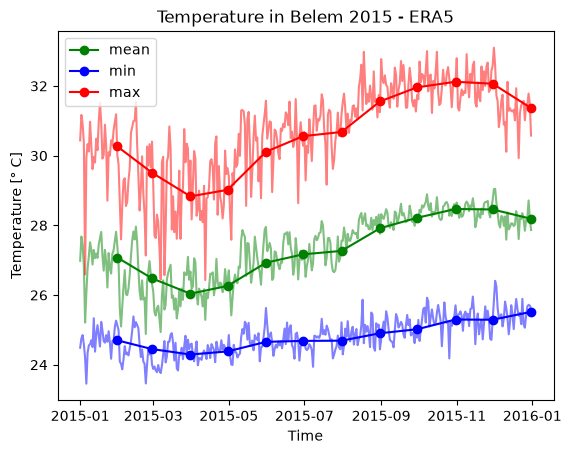

In [9]:
# Plot means together with daily temperatur

plt.figure()
plt.plot(belem_tas_monthly_mean["time"], belem_tas_monthly_mean["tas"], marker="o", color="green", label = "mean")
plt.plot(belem_tas["time"], belem_tas["tas"], color="green", alpha = 0.5)
plt.plot(belem_tasmin_monthly_mean["time"], belem_tasmin_monthly_mean["tasmin"], marker = "o", color="blue", label = "min")
plt.plot(belem_tasmin["time"], belem_tasmin["tasmin"], color="blue", alpha = 0.5)
plt.plot(belem_tasmax_monthly_mean["time"], belem_tasmax_monthly_mean["tasmax"], marker = "o", color="red",label = "max")
plt.plot(belem_tasmax["time"], belem_tasmax["tasmax"], color="red", alpha = 0.5)
plt.title("Temperature in Belem 2015 - ERA5")
plt.xlabel("Time")
plt.ylabel("Temperature [° C]")
plt.legend()



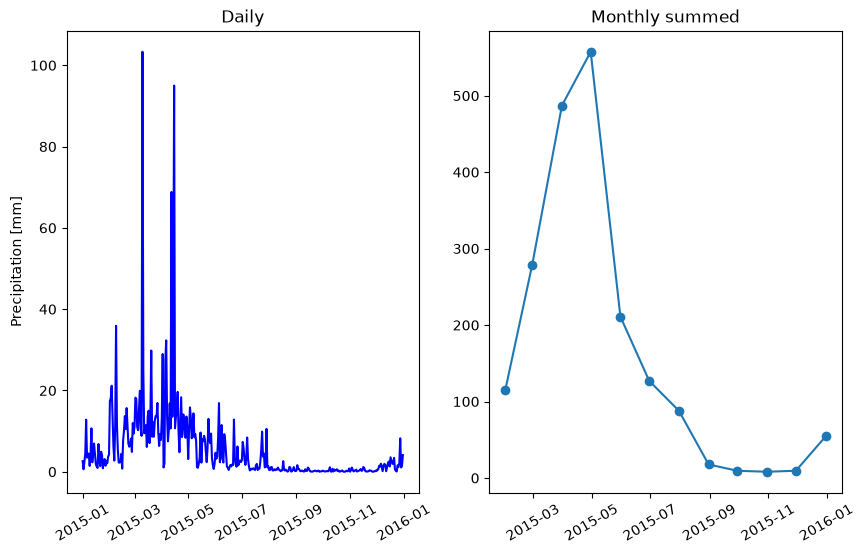

In [10]:
# Plot precipitation (monthly sum)

fig, axs = plt.subplots(1,2, figsize=(10,6))

axs[0].plot(belem_pr["time"], belem_pr["pr"], color = "blue")
axs[0].set_ylabel("Precipitation [mm]")
axs[0].set_title("Daily")
axs[0].tick_params(axis="x", rotation=30)
axs[1].plot(belem_pr_monthly_sum["time"], belem_pr_monthly_sum["pr"], marker="o")
axs[1].set_title("Monthly summed")
axs[1].tick_params(axis="x", rotation=30)


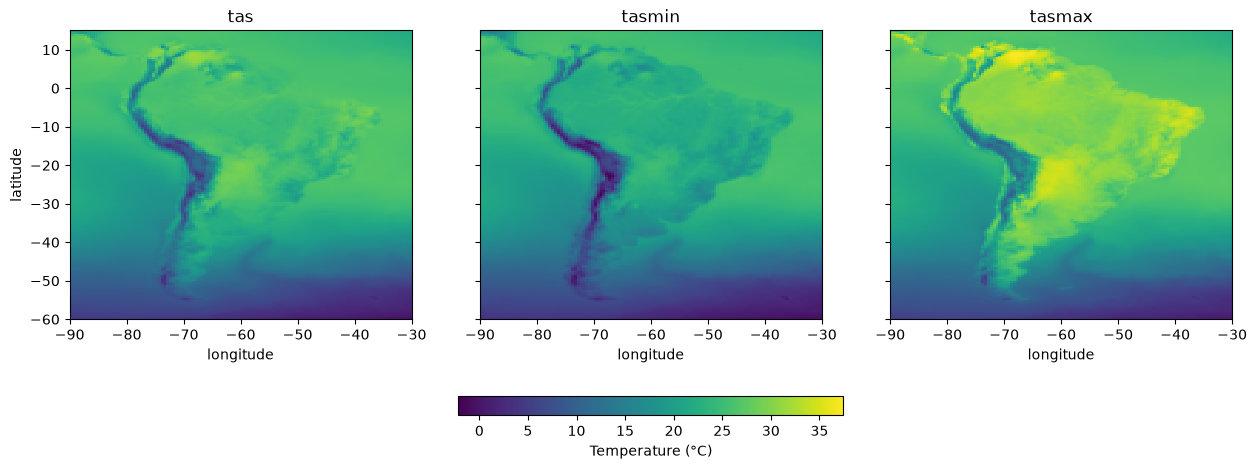

In [11]:
# Plot for a given month on the map

# Define common skala 
vmin = min(
    tas_monthly_mean["tas"].isel(time=1).min(),
    tasmin_monthly_mean["tasmin"].isel(time=1).min(),
    tasmax_monthly_mean["tasmax"].isel(time=1).min(),
).values

vmax = max(
    tas_monthly_mean["tas"].isel(time=1).max(),
    tasmin_monthly_mean["tasmin"].isel(time=1).max(),
    tasmax_monthly_mean["tasmax"].isel(time=1).max(),
).values

# Create subplot
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)

# tas
im1 = tas_monthly_mean["tas"].isel(time=1).plot(
    ax=axes[0], add_colorbar=False, vmin=vmin, vmax=vmax
)
axes[0].set_title("tas")
axes[0].set_ylabel("latitude")

# tasmin
im2 = tasmin_monthly_mean["tasmin"].isel(time=1).plot(
    ax=axes[1], add_colorbar=False, vmin=vmin, vmax=vmax
)
axes[1].set_title("tasmin")
axes[1].set_ylabel("")

# tasmax
im3 = tasmax_monthly_mean["tasmax"].isel(time=1).plot(
    ax=axes[2], add_colorbar=False, vmin=vmin, vmax=vmax
)
axes[2].set_title("tasmax")
axes[2].set_ylabel("")

# Common colorbar for all
cbar = fig.colorbar(im1, ax=axes, orientation="horizontal", fraction=0.05, pad=0.2)
cbar.set_label("Temperature (°C)")

plt.show()


Text(0.5, 0, 'longitude')

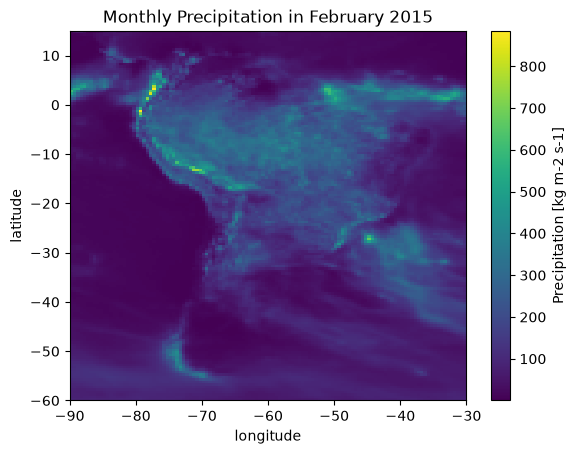

In [12]:
plt.figure()
pr_monthly_sum["pr"].isel(time=1).plot()
plt.title("Monthly Precipitation in February 2015")
plt.ylabel("latitude")
plt.xlabel("longitude")

In [13]:
# Create data set
T_southamerica = xr.Dataset({"Tavg": tas_monthly_mean["tas"], "Tmin": tasmin_monthly_mean["tasmin"], "Tmax": tasmax_monthly_mean["tasmax"]})
P_southamerica = xr.Dataset({"pr": pr_monthly_sum["pr"]})

In [14]:
# Cut out variables

# Load country mask

# Local path
country_mask_binary_path = DATA_DIR / "countrymasks-binary_30arcmin.nc"
#country_mask_binary_fractional_path = DATA_DIR / "countrymasks-fractional_30arcmin.nc"

country_mask_binary = xr.open_dataset(country_mask_binary_path)
country_mask_binary = country_mask_binary.rename({"lat": "latitude", "lon": "longitude"})

In [15]:
# cut out for southamerica

# lon and lat values for south america
lon_min, lon_max = -90, -30
lat_min, lat_max = -60, 15

# cut
world_mask_binary_southamerica = country_mask_binary["m_world"].sel(longitude=slice(lon_min, lon_max), latitude=slice(lat_max, lat_min))

#world_mask_binary_southamerica.plot()


In [16]:
T_land = T_southamerica.where(world_mask_binary_southamerica == 1)
P_land = P_southamerica.where(world_mask_binary_southamerica == 1)

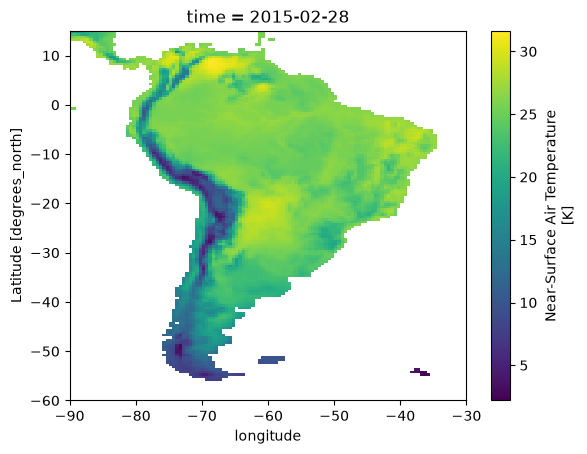

In [17]:
T_land["Tavg"].isel(time=1).plot()

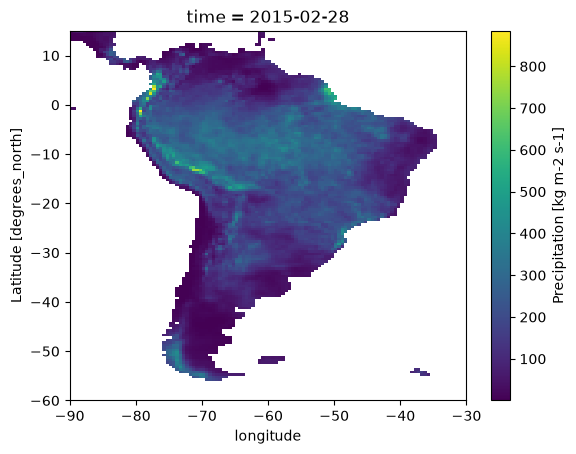

In [18]:
P_land["pr"].isel(time=1).plot()